<a href="https://colab.research.google.com/github/alibaba35t/ViewCountPredictor/blob/main/view_count_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import os


In [3]:
df = pd.read_csv("/content/Instagram_Analytics_organized.csv")
df = df.drop(columns=df.columns[df.columns.str.contains('^Unnamed')])
X = df.drop(columns="target").astype(np.float32)
y = df["target"].astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = torch.FloatTensor(X_train_scaled)
y_train = torch.FloatTensor(y_train.values).unsqueeze(1)

X_test = torch.FloatTensor(X_test_scaled)
y_test = torch.FloatTensor(y_test.values).unsqueeze(1)


train_dataset = TensorDataset(X_train,y_train)
train_loader = DataLoader(train_dataset, batch_size=64,shuffle=True)

input_dimension = X_train.shape[1]

print(df["target"].value_counts())

target
0    22499
1     7500
Name: count, dtype: int64


In [7]:
class ViewPredictorModel(nn.Module):
  def __init__(self,input_dimension):
    super(ViewPredictorModel, self).__init__()
    self.layer_1 = nn.Linear(input_dimension,128)
    self.bn1 = nn.BatchNorm1d(128)

    self.layer_2 = nn.Linear(128,64)
    self.bn2 = nn.BatchNorm1d(64)

    self.layer_3 = nn.Linear(64,1)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()
    self.dropout = nn.Dropout(p = 0.2)

  def forward(self, x):
    x = self.relu(self.bn1(self.layer_1(x)))
    x = self.dropout(x)
    x = self.relu(self.bn2(self.layer_2(x)))
    x = self.dropout(x)
    x = self.layer_3(x)
    return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model = ViewPredictorModel(input_dimension=input_dimension).to(device)



criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [8]:
os.makedirs("model_checkpoints", exist_ok=True)


In [9]:
epochs = 100

for epoch in range(epochs):
  model.train()
  epoch_loss = 0
  for batch_X, batch_y in train_loader:

        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

  if (epoch + 1) % 5 == 0 or epoch == 0:
      avg_loss = epoch_loss / len(train_loader)
      print(f"loss:{avg_loss}")

      checkpoint_path = f"model_checkpoints/model_epoch_{epoch+1:02d}.pt"

      torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
      }, checkpoint_path)


loss:0.5787616752783458
loss:0.5614931996663411
loss:0.5576739021142324
loss:0.5542336604595184
loss:0.550921258131663
loss:0.5484359708627065
loss:0.544189968029658
loss:0.5408456048965454
loss:0.5398401026725769
loss:0.537493524869283
loss:0.5353503719170888
loss:0.5357960987885793
loss:0.5295733654499054
loss:0.5300362571875255
loss:0.5279509199460347
loss:0.5269665873845418
loss:0.5216675002574921
loss:0.5208186348279317
loss:0.520600484530131
loss:0.5181515406767527
loss:0.5169018061161041


In [10]:
loaded_model = ViewPredictorModel(input_dimension=X_test.shape[1]).to(device)


checkpoint_path = "model_checkpoints/model_epoch_95.pt"


checkpoint = torch.load(checkpoint_path, map_location=device)


loaded_model.load_state_dict(checkpoint['model_state_dict'])


loaded_model.eval()

X_test_tensor = X_test.to(device)
y_test_tensor = y_test.to(device)

with torch.no_grad():

    raw_predictions = loaded_model(X_test_tensor)

    predicted_classes = (raw_predictions >= 0.5).float()

    correct_predictions = (predicted_classes == y_test_tensor).sum().item()
    total_samples = y_test_tensor.size(0)

    accuracy = (correct_predictions / total_samples) * 100

print("=========================================")
print(f"{accuracy:.2f}")
print("=========================================")

75.00


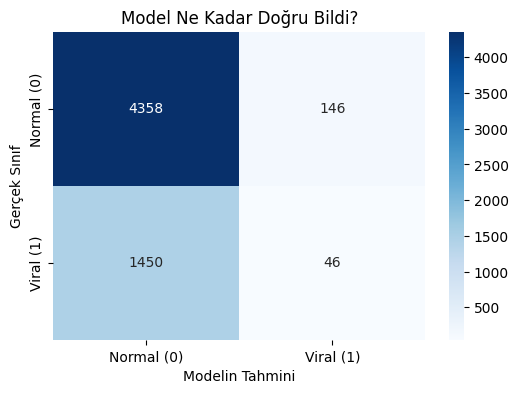


📋 DETAYLI BAŞARI RAPORU:
              precision    recall  f1-score   support

      Normal       0.75      0.97      0.85      4504
       Viral       0.24      0.03      0.05      1496

    accuracy                           0.73      6000
   macro avg       0.49      0.50      0.45      6000
weighted avg       0.62      0.73      0.65      6000



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

with torch.no_grad():
    logits = loaded_model(X_test_tensor.to(device))
    raw_predictions = torch.sigmoid(logits)
    predicted_classes = (raw_predictions >= 0.5).float().cpu().numpy()
    actual_classes = y_test_tensor.cpu().numpy()

# 1. Karmaşıklık Matrisini Hesapla
cm = confusion_matrix(actual_classes, predicted_classes)

# 2. Ekrana Çizdir
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal (0)", "Viral (1)"],
            yticklabels=["Normal (0)", "Viral (1)"])
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Modelin Tahmini')
plt.title('Model Ne Kadar Doğru Bildi?')
plt.show()

# 3. Detaylı Raporu Yazdır
print("\n📋 DETAYLI BAŞARI RAPORU:")
print(classification_report(actual_classes, predicted_classes, target_names=["Normal", "Viral"]))